# gCastle API Overview

This notebook explores the core APIs and components of gCastle,
a causal structure learning toolchain by Huawei Noah's Ark Lab.

We'll learn how to:
- Generate synthetic causal data with known ground truth
- Run various causal discovery algorithms
- Evaluate results using standard metrics
- Visualize learned causal structures

## Setup

In [31]:
# Load extension for auto-reload on edit.
%load_ext autoreload
%autoreload 2
%matplotlib inline

import logging
import warnings

logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import helpers.htutorial as mtumsuti
import helpers.hnotebook as hnotebo

hnotebo.config_notebook()

ModuleNotFoundError: No module named 'tutorial_utils'

In [33]:
import castle

print(castle.__name__)
print("Version:", castle.__version__)

castle
Version: 1.0.4


In [34]:
import tutorials.gCastle.gCastle_utils as tgcasti

## Part 1: Data Generation

gCastle provides utilities to generate synthetic causal data with known DAGs.
This is essential for testing and validating causal discovery algorithms.

In [21]:
# Generate synthetic data with a 5-node DAG.
n_nodes = 5
n_samples = 500

data, true_dag = tgcasti.generate_synthetic_data(
    n_nodes=n_nodes,
    n_edges=5,
    n_samples=n_samples,
    seed=42,
)

print(f"Generated data shape: {data.shape}")
print(f"Data columns: {list(data.columns)}")
print("\nFirst 5 rows of synthetic data:")
print(data.head())

INFO:root:Finished synthetic dataset


Generated data shape: (500, 5)
Data columns: ['X0', 'X1', 'X2', 'X3', 'X4']

First 5 rows of synthetic data:
         X0        X1        X2        X3        X4
0  0.279041 -0.946130 -0.381910 -2.701917 -0.369522
1  1.010515  0.461821 -0.413451  2.261998  0.204549
2 -0.580878 -0.929402 -0.828584 -3.193537 -1.031576
3 -0.525170 -2.435801 -0.545169 -3.171103 -0.529298
4 -0.571380 -2.884292 -2.502760 -5.950467  0.618687


In [22]:
print(true_dag)

[[0. 1. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


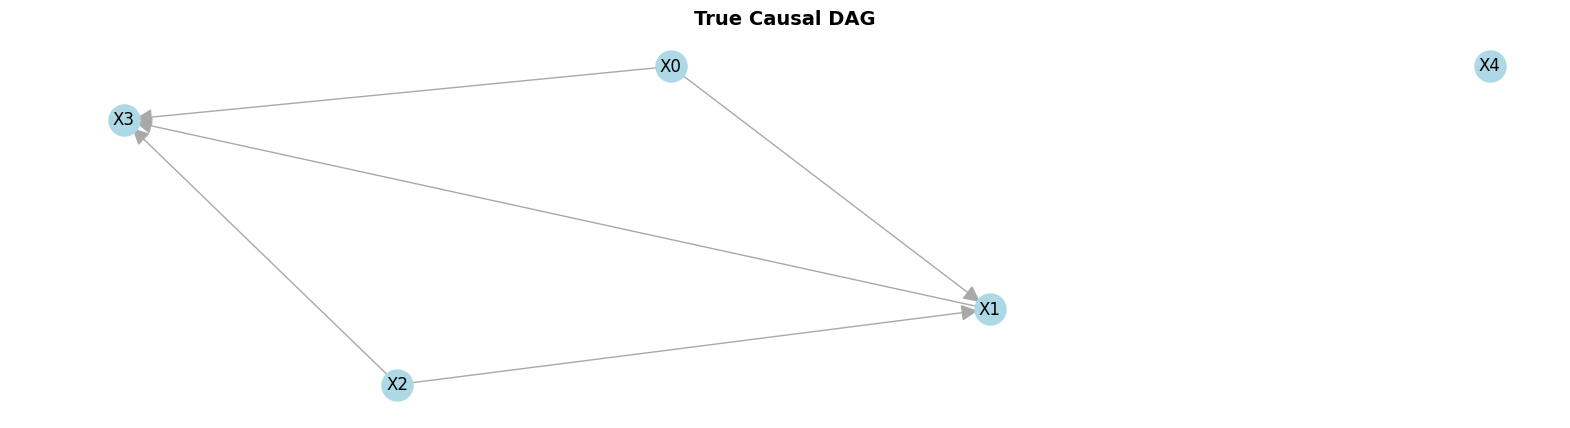

In [26]:
# Visualize the true causal structure.
fig = tgcasti.visualize_dag(
    true_dag,
    title="True Causal DAG",
)

## Part 2: Constraint-Based Algorithm (PC)

The PC (Peter-Clark) algorithm is a constraint-based approach that uses
conditional independence tests to discover causal relationships. The key
parameter is **alpha** (significance level): higher values → fewer edges detected.</cell_type="markdown">
</invoke>

In [29]:
# Create interactive widget for alpha parameter.
alpha_slider, alpha_box = mtumsuti.build_widget_control(
    name="alpha",
    description="significance level for independence tests",
    min_val=0.01,
    max_val=0.20,
    step=0.01,
    initial_value=0.05,
    is_float=True,
)

display(alpha_box)

ModuleNotFoundError: No module named 'tutorial_utils'

In [ ]:
# **Purpose**: Run the PC algorithm with interactive alpha control
# **What it does**: Learns causal structure using conditional independence tests at the selected significance level
# **Key insight**: Lower alpha (more conservative) detects fewer edges; higher alpha (less conservative) detects more

# Run the PC algorithm with the selected alpha value
pc_adjacency = tgcasti.run_pc_algorithm(
    data.values,
    alpha=alpha_slider.value,
)

print(
    f"PC algorithm (alpha={alpha_slider.value:.2f}) - Estimated adjacency matrix:"
)
print(pc_adjacency)

In [ ]:
# **Purpose**: Evaluate PC algorithm performance dynamically
# **What it shows**: Metrics (F1, SHD, FDR, TPR) comparing estimated vs true causal structure
# **Key insight**: Different alpha values trade off sensitivity (TPR) vs specificity (lower FDR)

from ipywidgets import Output

output = Output()


@output.capture()
def update_metrics(change):
    """Re-evaluate metrics whenever alpha changes."""
    pc_adjacency = tgcasti.run_pc_algorithm(
        data.values,
        alpha=alpha_slider.value,
    )

    pc_metrics = tgcasti.evaluate_causal_discovery(
        true_dag,
        pc_adjacency,
    )

    print(
        f"\nPC Algorithm Performance Metrics (alpha={alpha_slider.value:.2f}):"
    )
    for metric_name, value in pc_metrics.items():
        print(f"  {metric_name}: {value:.4f}")


# Connect alpha slider to metrics update
alpha_slider.observe(update_metrics, names="value")

# Display initial metrics
display(output)
update_metrics(None)

## Part 3: Score-Based Algorithm (GES)

GES (Greedy Equivalence Search) uses a score-based approach,
optimizing a score function over equivalence classes.

In [ ]:
# Run the GES algorithm.
ges_adjacency = tgcasti.run_ges_algorithm(data.values)

print("GES algorithm - Estimated adjacency matrix:")
print(ges_adjacency)

In [ ]:
# Evaluate GES results.
ges_metrics = tgcasti.evaluate_causal_discovery(
    true_dag,
    ges_adjacency,
)

print("\nGES Algorithm Performance Metrics:")
for metric_name, value in ges_metrics.items():
    print(f"  {metric_name}: {value:.4f}")

## Part 4: Gradient-Based Algorithms

NOTEARS (No-Tears) and GOLEM are modern gradient-based algorithms
that can handle large-scale problems efficiently.

In [ ]:
# Run NOTEARS algorithm with L2 loss (linear relationships).
notears_adjacency = tgcasti.run_notears_algorithm(
    data.values,
    lambda1=0.0,
    loss_type="l2",
)

print("NOTEARS algorithm - Estimated adjacency matrix:")
print(notears_adjacency)

In [ ]:
# Evaluate NOTEARS results.
notears_metrics = tgcasti.evaluate_causal_discovery(
    true_dag,
    notears_adjacency,
)

print("\nNOTEARS Algorithm Performance Metrics:")
for metric_name, value in notears_metrics.items():
    print(f"  {metric_name}: {value:.4f}")

## Part 5: Algorithm Comparison

Let's compare the performance of different algorithms on the same data.

In [ ]:
# Compare all algorithms.
algorithms_results = {
    "PC": pc_adjacency,
    "GES": ges_adjacency,
    "NOTEARS": notears_adjacency,
}

In [ ]:
# Visualize comparison of all three algorithms.
fig = tgcasti.compare_dags(
    true_dag,
    algorithms_results,
)
fig.suptitle(
    "Causal Discovery Algorithm Comparison", fontsize=16, fontweight="bold"
)

In [ ]:
# Print performance summary.
print("\n" + "=" * 70)
print("PERFORMANCE COMPARISON SUMMARY")
print("=" * 70)

algorithms = ["PC", "GES", "NOTEARS"]
metrics_keys = ["F1", "SHD", "FDR", "TPR"]

all_metrics = {
    "PC": pc_metrics,
    "GES": ges_metrics,
    "NOTEARS": notears_metrics,
}

print(f"{'Algorithm':<15} {' | '.join([f'{m:>6}' for m in metrics_keys])}")
print("-" * 70)

for alg in algorithms:
    metrics = all_metrics[alg]
    values = [f"{metrics[m]:>6.3f}" for m in metrics_keys]
    print(f"{alg:<15} {' | '.join(values)}")

## Part 6: Thresholding Weighted Adjacency Matrices

Some algorithms return weighted adjacency matrices.
We can convert them to binary by applying a threshold.

In [ ]:
# Apply threshold to NOTEARS output.
notears_thresholded = tgcasti.thresholded_dag(
    notears_adjacency,
    threshold=0.3,
)

print("NOTEARS thresholded adjacency (threshold=0.3):")
print(notears_thresholded)

In [ ]:
# Evaluate thresholded results.
notears_thresh_metrics = tgcasti.evaluate_causal_discovery(
    true_dag,
    notears_thresholded,
)

print("\nNOTEARS Thresholded Performance Metrics:")
for metric_name, value in notears_thresh_metrics.items():
    print(f"  {metric_name}: {value:.4f}")